---
title: Training with variable length data
image: ./images/vld.png 
description: Building a dataloader to train deep learning models on variable length data
format:
    html:
        toc: true
---

There are several different ways we can deal with variable length data when training deep learning models:

- Cut or pad all the samples to the maximum length in the whole dataset
- Cut or pad samples to the maximum length whithin a mini-batch
- Split the dataset into multiple buckets with samples of similar lentgh.   

I will describe the third option as it imposes the least memory and computational overhead. This option can be used to train CNNs, RNNs or transformers with relative positional encoding, since they can be trained on varibale lenght data. For example we can train Wav2Vec 2.0 model with audio samples of different length as it encodes audio with CNN and is using convolutional relative positional encoding as well. 

![](./images/dl.png)


# 1. Splitting the data

Generating dataset with variable length items.

In [43]:
from random import randint
import torch
import pandas as pd

# generate dataset
min_length = 2
max_length = 20
size = 1000
dummy_y = 0

dataset = [(torch.randn(randint(min_length,max_length)),dummy_y) for _ in range(size)] 

Create a dataframe with information about items length

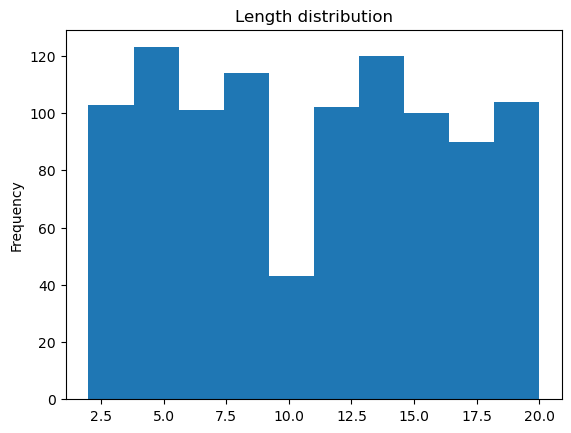

In [56]:
df = pd.DataFrame([(id,len(x)) for id,(x,y) in enumerate(dataset)], columns=['id','length'])
df.length.plot(kind='hist',title="Length distribution");

Split data into bukets

In [57]:
nbuckets=10
df['bucket'] = pd.cut(df.length, bins=nbuckets, labels=range(nbuckets))

# 2. Create dataloaders

Create DataSet class, which is using a dataframe with items ids to retrieve them from the original dataset.

In [46]:
from torch.utils.data import DataLoader
from torch.nn.functional import pad

class DataSet:
    def __init__(self,dataframe,data):
        self.df = dataframe.reset_index(drop=True) # items ids
        self.data = data
    
    def __getitem__(self,index):
        id = self.df.iloc[index].id # get item by id from the original dataset
        return self.data[id]
    
    def __len__(self): return len(self.df)

Collate function adds padding according to the maximum length in a batch

In [47]:
def collate_fn(batch):
    xs,ys = [list(b) for b in (zip(*batch))]
    maxl = max([len(x) for x in xs]) # maxl in a batch
    for i in range(len(xs)):
        xs[i] = pad(xs[i],(0,maxl-len(xs[i]))) # pad to maxl
    x = torch.stack(xs)
    y = torch.tensor(ys)
    return (x,y)

Create dataloaders for each bucket

In [58]:
def create_dataloader(dataframe,bs=4): 
    return DataLoader(DataSet(dataframe, dataset), bs, shuffle = True, collate_fn=collate_fn)

dataloaders = []
for bucket_id in df.bucket.unique():
    dl = create_dataloader(df[df.bucket==bucket_id])
    dataloaders.append(dl)

# 3. Create random iterator 

The iterator takes iterators from the dataloaders and randomly chooses one at the each `next` call

In [50]:
from random import choice

class DLIterator:
    def __init__(self, dls) -> None:
        self.iters = [iter(dl) for dl in dls]

    def __iter__(self): return self

    def __next__(self):
            for _ in range(len(self.iters)): # iterate in case some are empty
                try:
                    it = choice(self.iters)
                    return next(it)
                except StopIteration:
                    self.iters.remove(it)
            raise StopIteration

            
class MultiDataLoader:
    '''Combining multiple dataloaders.'''
    def __init__(self,dataloaders) -> None:
        self.dls=dataloaders

    def __iter__(self):
        return DLIterator(self.dls)

    def __len__(self):
        return sum(map(len, self.dls))

Check the distribution of batch lengths for the obtained dataloader

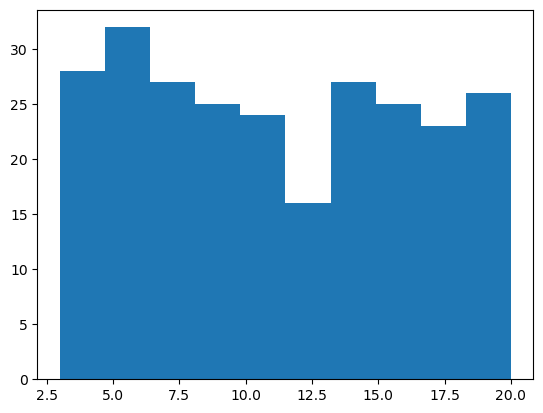

In [59]:
import matplotlib.pyplot as plt

batch_sizes = [xb.shape[1] for xb,_ in MultiDataLoader(dataloaders)]
plt.hist(batch_sizes);

Visualize batch lengths:

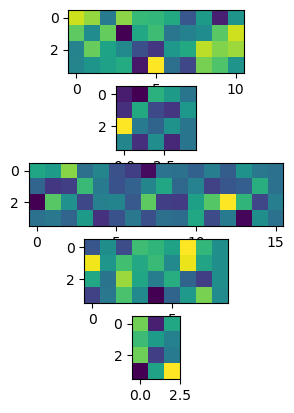

In [62]:
it = iter(MultiDataLoader(dataloaders))
_,ax = plt.subplots(5)
for i in range(5):
    ax[i].imshow(next(it)[0])